In [1]:
import sys
import os

sys.path.append('..') #allows importing from parent directory

from model.malware_model import MalwareModel 
import matplotlib.pyplot as plt
import pandas as pd

print("✅ Imports successful!")

✅ Imports successful!


In [2]:
print("Starting Simulation...")

model = MalwareModel(number_of_devices=100,
    rollout_strategy="staged",
    devices_per_step=5,
    execution_probability=0.3,
    detection_delay=5
                     )

print("✅ Model created successfully!")
print(f"   - Number of devices: {model.number_of_devices}")
print(f"   - Rollout strategy: {model.rollout_strategy}")

#Run for 50 time steps
for  i in range(50):
    model.step()
    if i % 10 == 0:  # Progress indicator
        print(f"  Step {i}/50 completed")

print("✅ Model Created!")


Starting Simulation...
✅ Model created successfully!
   - Number of devices: 100
   - Rollout strategy: staged
  Step 0/50 completed
  Step 10/50 completed
  Step 20/50 completed
  Step 30/50 completed
  Step 40/50 completed
✅ Model Created!


In [5]:
#Get the collected data
print("Extracting simulation..")

df = model.datacollector.get_model_vars_dataframe()

# Preview the data
print("\n Data extracted successfully!")
print(f" Total time steps recorded: {len(df)}")
print(f" Variables tracked: {list(df.columns)}")

print("\n First 10 rows of data:")
print(df.head(10))

print("\n Last 10 rows of data:")
print(df.tail(10))

print("\n Summary statistics:")
print(df.describe())



Extracting simulation..

 Data extracted successfully!
 Total time steps recorded: 50
 Variables tracked: ['Susceptible', 'Exposed', 'Infected', 'Recovered', 'ServerCompromised']

 First 10 rows of data:
   Susceptible  Exposed  Infected  Recovered  ServerCompromised
0          100        0         0          0              False
1          100        0         0          0              False
2          100        0         0          0              False
3          100        0         0          0               True
4          100        0         0          0               True
5          100        0         0          0               True
6          100        0         0          0               True
7          100        0         0          0               True
8          100        0         0          0               True
9          100        0         0          0               True

 Last 10 rows of data:
    Susceptible  Exposed  Infected  Recovered  ServerCompromised
40 

Creating SEIR plot...


<Figure size 1200x700 with 0 Axes>

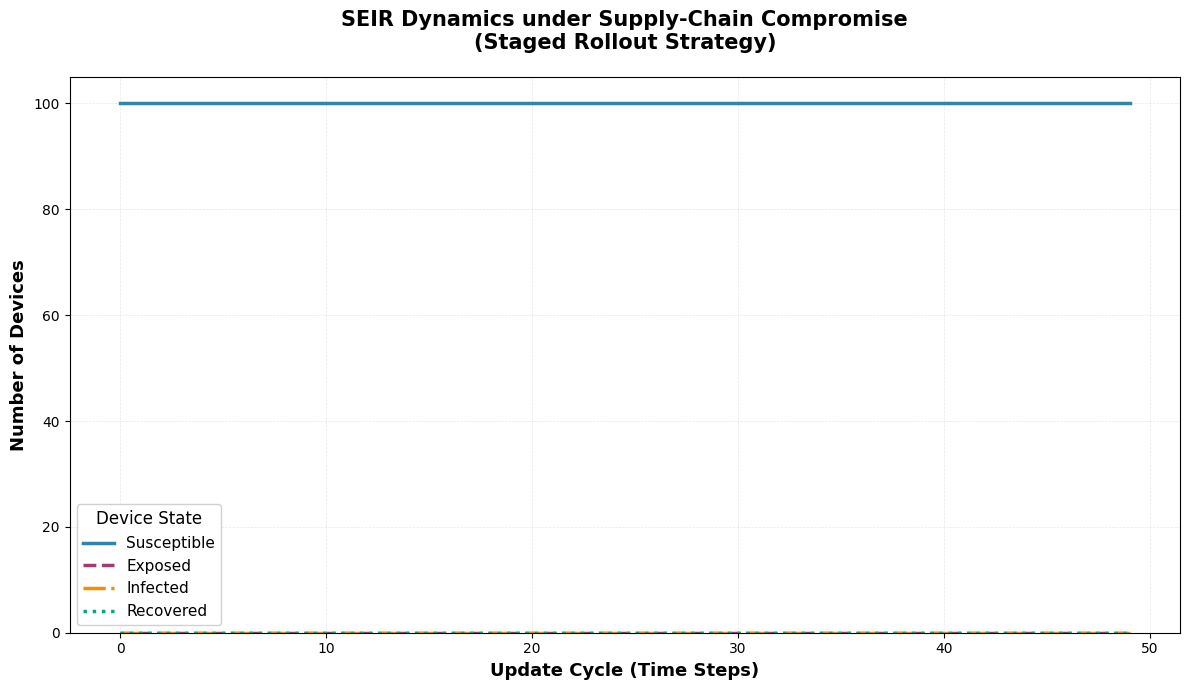

✅ Plot generated successfully!


In [4]:
# Create the SEIR dynamics plot
print("Creating SEIR plot...")

#Create a figure with good size
plt.figure(figsize=(12,7))

# Plot all four states
df[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],  # Different line styles
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']  # Custom colors
)

# Customize the plot
plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics under Supply-Chain Compromise\n(Staged Rollout Strategy)", 
          fontsize=15, fontweight='bold', pad=20)

# Add legend with better positioning
plt.legend(
    title="Device State",
    loc="best", 
    fontsize=11,
    title_fontsize=12,
    framealpha=0.9
)

# Add grid for better readability
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)

# Add y-axis limit
plt.ylim(0, model.number_of_devices + 5)

# Tight layout to prevent label cutoff
plt.tight_layout()

# Display the plot
plt.show()

print("✅ Plot generated successfully!")




In [2]:
import mesa
print(mesa.__version__)



3.3.0


In [5]:
# Cell 6: Diagnostic - Check if the server got compromised
print(" DIAGNOSTIC REPORT")
print("=" * 60)
print(f"Update Server Compromised: {model.update_server.is_compromised}")
print(f"Compromise Step: {model.update_server.compromise_step}")
print(f"Current Step: {model.current_step}")
print()
print(f"Attacker Skill Level: {model.attacker.skill_level}")
print(f"Server Security Level: {model.update_server.security_level}")
print()
print("Device States:")
for state in ["S", "E", "I", "R"]:
    count = sum(1 for d in model.devices if d.state == state)
    print(f"  {state}: {count} devices")

 DIAGNOSTIC REPORT
Update Server Compromised: True
Compromise Step: 5
Current Step: 50

Attacker Skill Level: 0.6
Server Security Level: 0.6

Device States:
  S: 0 devices
  E: 0 devices
  I: 0 devices
  R: 100 devices


 Saving plot to file...


<Figure size 1200x700 with 0 Axes>

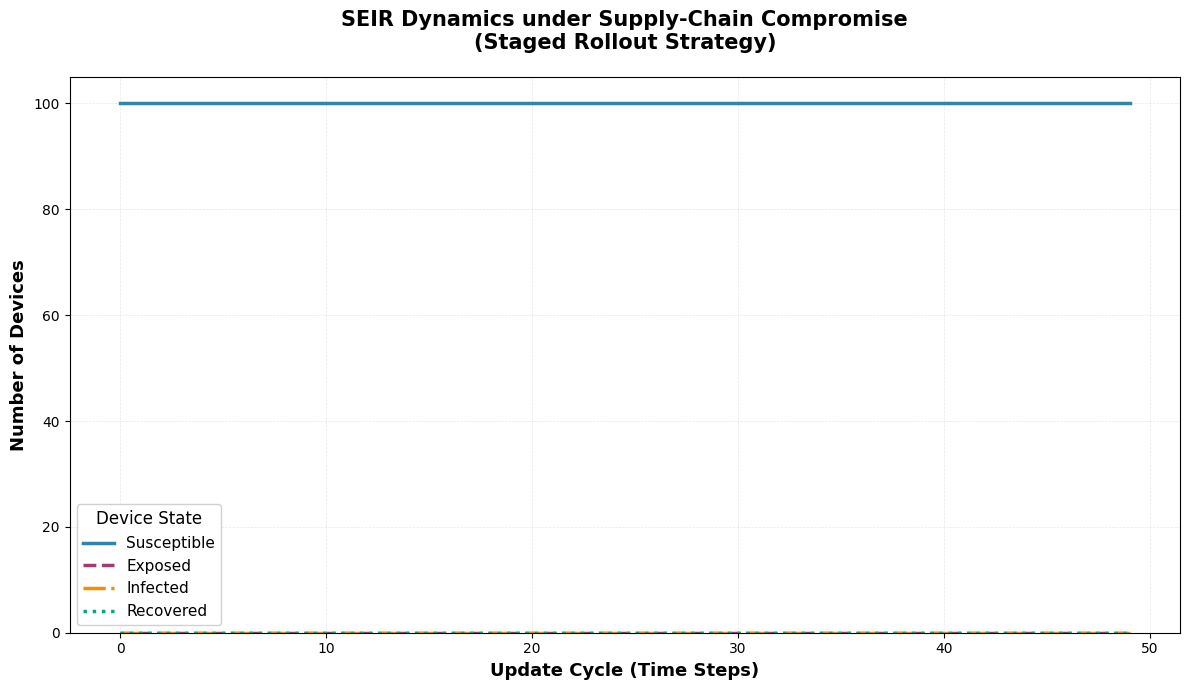

 Plot saved to: ../visualization/seir_plot.png
   You can now use this image in your report!


In [6]:
# Cell : Save the plot as a high-quality image
print(" Saving plot to file...")

# Recreate the plot (same code as before)
plt.figure(figsize=(12, 7))

df[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)

plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics under Supply-Chain Compromise\n(Staged Rollout Strategy)", 
          fontsize=15, fontweight='bold', pad=20)
plt.legend(title="Device State", loc="best", fontsize=11, title_fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, model.number_of_devices + 5)
plt.tight_layout()

# Save the figure
output_path = "../visualization/seir_plot.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" Plot saved to: {output_path}")
print("   You can now use this image in your report!")

In [7]:
print(" Running NEW simulation with guaranteed compromise...")

# Create a new model with settings that GUARANTEE infection
model2 = MalwareModel(
    number_of_devices=100,
    rollout_strategy="full_push",  # Changed to full_push for faster spread
    devices_per_step=10,            # More devices per step
    execution_probability=0.8,      # Higher execution probability
    detection_delay=10              # Longer detection delay
)

# MANUALLY compromise the server to guarantee outbreak
model2.update_server.compromise(current_step=0)
print(f"✅ Server manually compromised at step 0")

# Run simulation
print("\n🔄 Running simulation...")
for i in range(50):
    model2.step()
    if i % 10 == 0:
        print(f"   Step {i}/50 completed")

print("\n✅ Simulation complete!")

# Check results
print("\n Final State Distribution:")
df2 = model2.datacollector.get_model_vars_dataframe()
print(df2.tail())

 Running NEW simulation with guaranteed compromise...
✅ Server manually compromised at step 0

🔄 Running simulation...
   Step 0/50 completed
   Step 10/50 completed
   Step 20/50 completed
   Step 30/50 completed
   Step 40/50 completed

✅ Simulation complete!

 Final State Distribution:
    Susceptible  Exposed  Infected  Recovered  ServerCompromised
45          100        0         0          0               True
46          100        0         0          0               True
47          100        0         0          0               True
48          100        0         0          0               True
49          100        0         0          0               True


 Creating plot for guaranteed outbreak scenario...


<Figure size 1200x700 with 0 Axes>

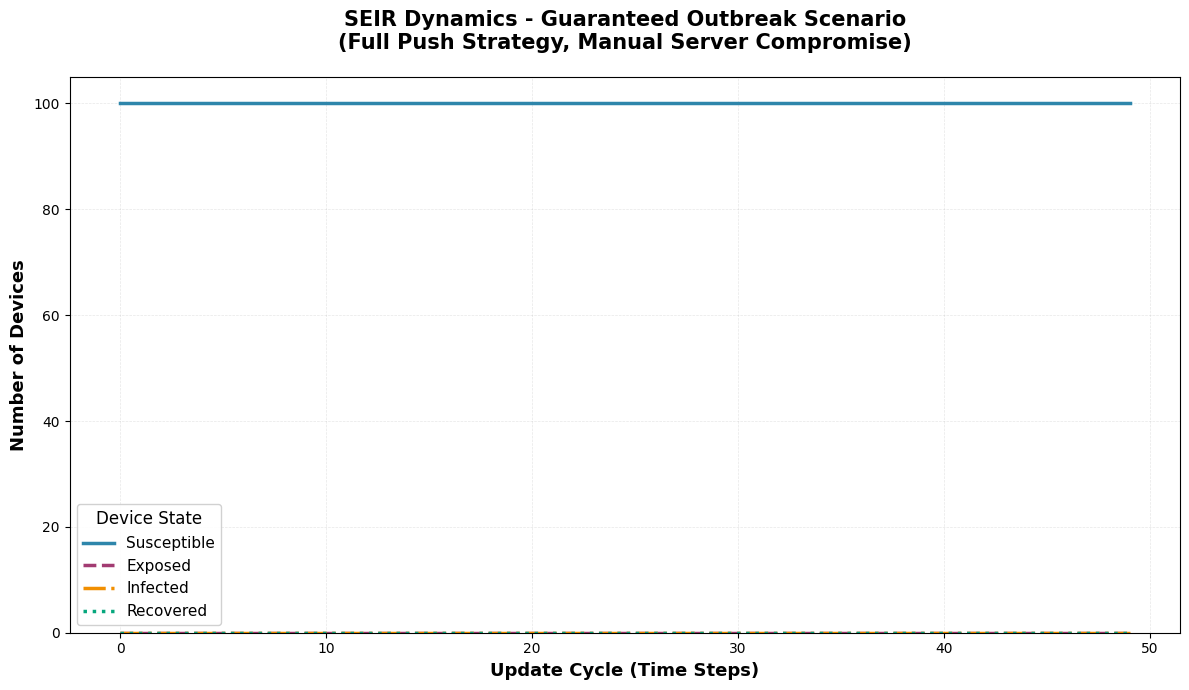

Plot generated!


In [8]:
# Create the plot for the guaranteed outbreak
print(" Creating plot for guaranteed outbreak scenario...")

plt.figure(figsize=(12, 7))

df2[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)

plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics - Guaranteed Outbreak Scenario\n(Full Push Strategy, Manual Server Compromise)", 
          fontsize=15, fontweight='bold', pad=20)

plt.legend(
    title="Device State",
    loc="best", 
    fontsize=11,
    title_fontsize=12,
    framealpha=0.9
)

plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, model2.number_of_devices + 5)
plt.tight_layout()
plt.show()

print("Plot generated!")

In [6]:
# Extract the data
print(" Extracting simulation data...")
df = model.datacollector.get_model_vars_dataframe()

# Show the full progression
print("\n Data over time (first 15 steps):")
print(df.head(15))

print("\n Data over time (last 10 steps):")
print(df.tail(10))

print(f"\n Total time steps recorded: {len(df)}")

 Extracting simulation data...

 Data over time (first 15 steps):
    Susceptible  Exposed  Infected  Recovered  ServerCompromised
0           100        0         0          0              False
1           100        0         0          0              False
2           100        0         0          0              False
3           100        0         0          0              False
4            52       15        29          4               True
5            23       10        52         15               True
6            10        9        56         25               True
7             6        3        56         35               True
8             2        3        54         41               True
9             1        3        44         52               True
10            1        0        41         58               True
11            0        0        35         65               True
12            0        0        31         69               True
13            0        0

 Creating SEIR plot...


<Figure size 1200x700 with 0 Axes>

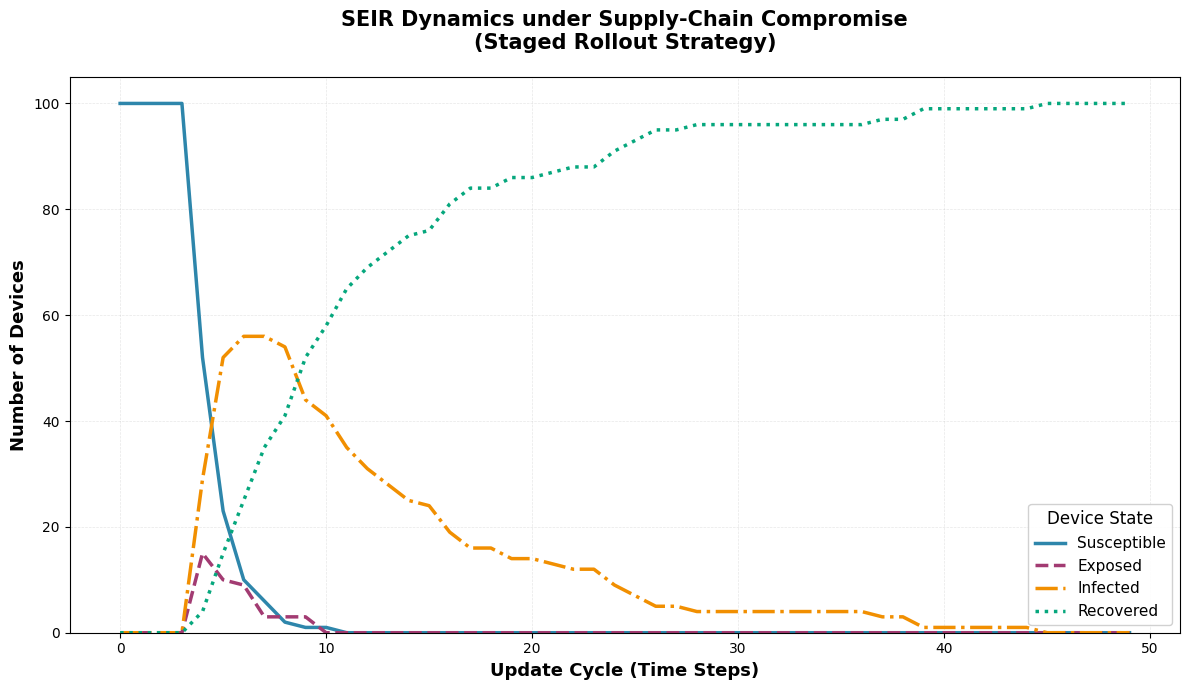

✅ Plot generated successfully!


In [7]:
print(" Creating SEIR plot...")

plt.figure(figsize=(12, 7))

df[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)

plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics under Supply-Chain Compromise\n(Staged Rollout Strategy)", 
          fontsize=15, fontweight='bold', pad=20)

plt.legend(title="Device State", loc="best", fontsize=11, 
           title_fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, 105)
plt.tight_layout()
plt.show()

print("✅ Plot generated successfully!")

 Saving plot to file...


<Figure size 1200x700 with 0 Axes>

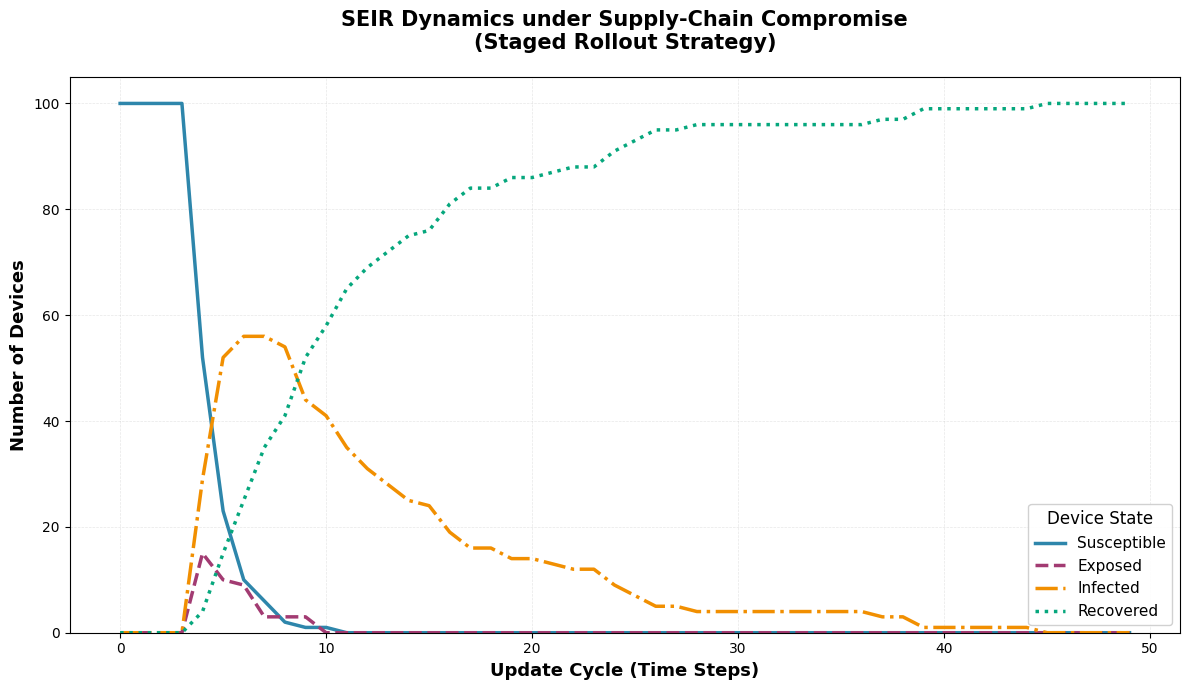

 Plot saved to: ../visualization/seir_plot.png
   You can now use this image in your report!


In [8]:
# Cell : Save the plot as a high-quality image
print(" Saving plot to file...")

# Recreate the plot (same code as before)
plt.figure(figsize=(12, 7))

df[["Susceptible", "Exposed", "Infected", "Recovered"]].plot(
    figsize=(12, 7),
    linewidth=2.5,
    style=['-', '--', '-.', ':'],
    color=['#2E86AB', '#A23B72', '#F18F01', '#06A77D']
)

plt.xlabel("Update Cycle (Time Steps)", fontsize=13, fontweight='bold')
plt.ylabel("Number of Devices", fontsize=13, fontweight='bold')
plt.title("SEIR Dynamics under Supply-Chain Compromise\n(Staged Rollout Strategy)", 
          fontsize=15, fontweight='bold', pad=20)
plt.legend(title="Device State", loc="best", fontsize=11, title_fontsize=12, framealpha=0.9)
plt.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
plt.ylim(0, model.number_of_devices + 5)
plt.tight_layout()

# Save the figure
output_path = "../visualization/seir_plot.png"
plt.savefig(output_path, dpi=300, bbox_inches='tight')
plt.show()

print(f" Plot saved to: {output_path}")
print("   You can now use this image in your report!")